# Notebook 03 — BiLSTM Training (Kaggle GPU)
**Project:** Product Review Sentiment Classification  
**Student:** Eeman Khalid (22F-3173) | BAI-8A  

Trains a **Bidirectional LSTM** model using PyTorch.  
⚠️ **Run this on Kaggle with GPU enabled (P100).**  
Expected runtime: ~25–40 minutes.

**After training, download from Output:**
- `lstm_model.pt`
- `lstm_vocab.json`
- `lstm_config.json`
- `lstm_confusion_test.png`

In [1]:
import os, sys, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/f223173eemankhalid/amazon-sentiment-processed/amazon_clean.csv


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────
DATA_PATH  = '/kaggle/input/datasets/f223173eemankhalid/amazon-sentiment-processed/amazon_clean.csv'
OUTPUT_DIR = '/kaggle/working/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────
CONFIG = {
    'vocab_size':   30_000,
    'embed_dim':    128,
    'hidden_dim':   256,
    'num_layers':   2,
    'dropout':      0.3,
    'num_classes':  3,
    'max_seq_len':  150,
    'batch_size':   64,
    'epochs':       10,
    'lr':           1e-3,
    'patience':     3,
}
print('Config:', CONFIG)

Config: {'vocab_size': 30000, 'embed_dim': 128, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3, 'num_classes': 3, 'max_seq_len': 150, 'batch_size': 64, 'epochs': 10, 'lr': 0.001, 'patience': 3}


In [4]:
# ── Load data ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows')
print(df['sentiment'].value_counts())

X = df['clean_text'].fillna('').values
y = df['label'].values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Loaded 1,176 rows
sentiment
positive    741
neutral     360
negative     75
Name: count, dtype: int64
Train: 822 | Val: 177 | Test: 177


In [5]:
# ── Build Vocabulary ──────────────────────────────────────────────────────
def build_vocab(texts, max_vocab=30_000):
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len):
    tokens = str(text).split()[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids += [0] * (max_len - len(ids))
    return ids

print('Building vocabulary...')
vocab = build_vocab(X_train, CONFIG['vocab_size'])
print(f'Vocab size: {len(vocab):,}')

with open(OUTPUT_DIR + 'lstm_vocab.json', 'w') as f:
    json.dump(vocab, f)
print('Vocabulary saved.')

Building vocabulary...
Vocab size: 4,089
Vocabulary saved.


In [6]:
# ── Dataset & DataLoader ──────────────────────────────────────────────────
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.encodings = [encode(t, vocab, max_len) for t in texts]
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return (
            torch.tensor(self.encodings[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

MAX_LEN = CONFIG['max_seq_len']
BATCH   = CONFIG['batch_size']

train_ds = ReviewDataset(X_train, y_train, vocab, MAX_LEN)
val_ds   = ReviewDataset(X_val,   y_val,   vocab, MAX_LEN)
test_ds  = ReviewDataset(X_test,  y_test,  vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f'Dataloaders ready. Train batches: {len(train_loader)}')

Dataloaders ready. Train batches: 13


In [7]:
# ── Model Architecture ────────────────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        embedded  = self.dropout(self.embedding(x))
        lstm_out, _ = self.lstm(embedded)
        pooled    = lstm_out.mean(dim=1)   # mean pooling
        return self.fc(self.dropout(pooled))

model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=CONFIG['embed_dim'],
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    num_classes=CONFIG['num_classes'],
    dropout=CONFIG['dropout']
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 2,892,419
BiLSTMClassifier(
  (embedding): Embedding(4089, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)


In [8]:
# ── Training utilities ────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader), correct/total, np.array(all_preds), np.array(all_labels)

In [9]:
# ── Training Loop ─────────────────────────────────────────────────────────
optimizer = Adam(model.parameters(), lr=CONFIG['lr'])
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

best_val_loss = float('inf')
patience_ctr  = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:02d}/{CONFIG["epochs"]} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_ctr = 0
        torch.save(model.state_dict(), OUTPUT_DIR + 'lstm_model.pt')
        print('  ✓ Best model checkpoint saved.')
    else:
        patience_ctr += 1
        if patience_ctr >= CONFIG['patience']:
            print(f'Early stopping triggered at epoch {epoch}.')
            break

print('\nTraining complete.')

Epoch 01/10 | Train Loss: 0.9368 Acc: 0.6083 | Val Loss: 0.8721 Acc: 0.6328
  ✓ Best model checkpoint saved.
Epoch 02/10 | Train Loss: 0.8354 Acc: 0.6290 | Val Loss: 0.8023 Acc: 0.6328
  ✓ Best model checkpoint saved.
Epoch 03/10 | Train Loss: 0.7730 Acc: 0.6582 | Val Loss: 0.7345 Acc: 0.7006
  ✓ Best model checkpoint saved.
Epoch 04/10 | Train Loss: 0.7089 Acc: 0.6886 | Val Loss: 0.7175 Acc: 0.6893
  ✓ Best model checkpoint saved.
Epoch 05/10 | Train Loss: 0.7751 Acc: 0.7056 | Val Loss: 0.7456 Acc: 0.7062
Epoch 06/10 | Train Loss: 0.6316 Acc: 0.7348 | Val Loss: 0.7396 Acc: 0.7175
Epoch 07/10 | Train Loss: 0.5505 Acc: 0.7579 | Val Loss: 0.7630 Acc: 0.6893
Early stopping triggered at epoch 7.

Training complete.


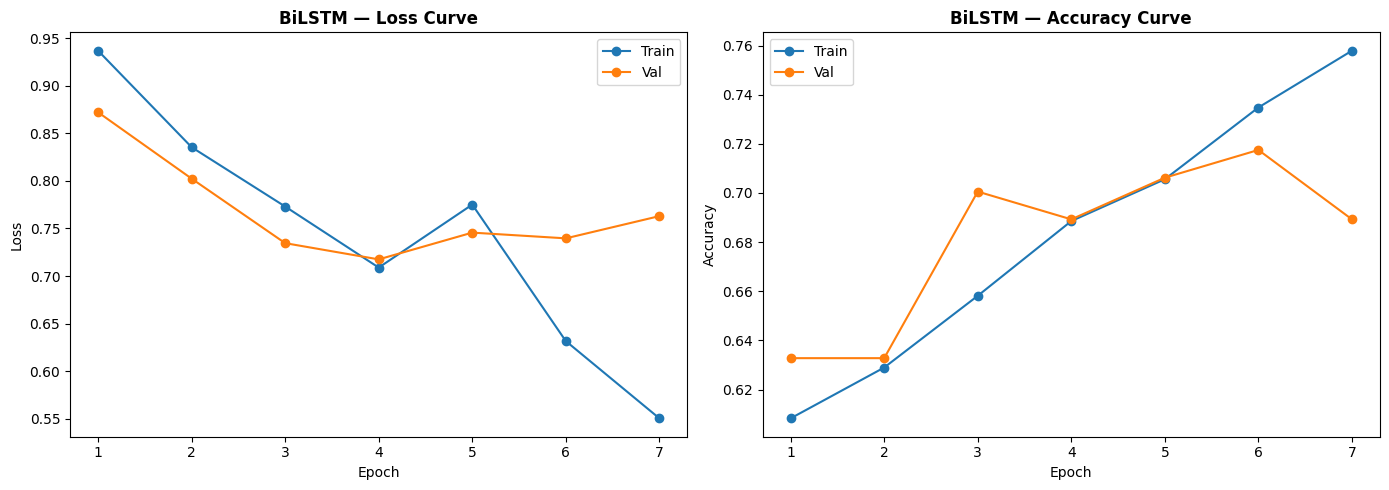

In [10]:
# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('BiLSTM — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs_ran, history['train_acc'], label='Train', marker='o')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   marker='o')
axes[1].set_title('BiLSTM — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'lstm_training_curves.png', dpi=150)
plt.show()

In [11]:
# ── Test Evaluation ───────────────────────────────────────────────────────
LABEL_NAMES = ['negative', 'neutral', 'positive']

print('Loading best checkpoint for test evaluation...')
model.load_state_dict(torch.load(OUTPUT_DIR + 'lstm_model.pt', map_location=DEVICE))

_, _, y_pred, y_true = eval_epoch(model, test_loader, criterion)

lstm_acc  = accuracy_score(y_true, y_pred)
lstm_prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
lstm_rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
lstm_f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('=== TEST RESULTS ===')
print(f'Accuracy  : {lstm_acc:.4f}')
print(f'Precision : {lstm_prec:.4f}')
print(f'Recall    : {lstm_rec:.4f}')
print(f'F1-Score  : {lstm_f1:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))

Loading best checkpoint for test evaluation...
=== TEST RESULTS ===
Accuracy  : 0.7006
Precision : 0.6774
Recall    : 0.7006
F1-Score  : 0.6363

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        11
     neutral       0.79      0.28      0.41        54
    positive       0.69      0.97      0.81       112

    accuracy                           0.70       177
   macro avg       0.49      0.42      0.41       177
weighted avg       0.68      0.70      0.64       177



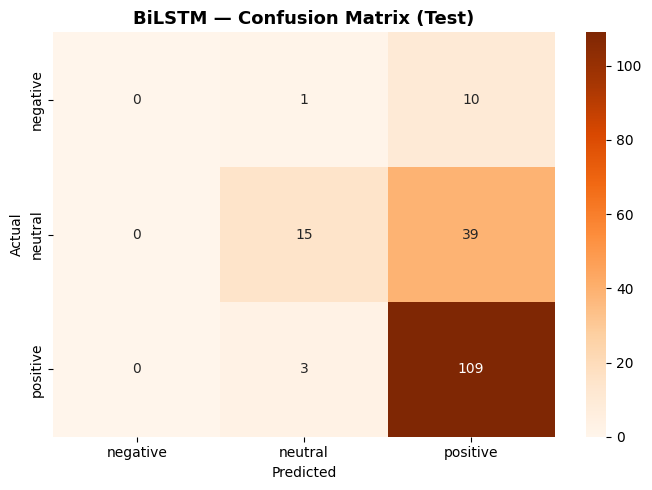

In [12]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('BiLSTM — Confusion Matrix (Test)', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'lstm_confusion_test.png', dpi=150)
plt.show()

In [13]:
# ── Save config + results ─────────────────────────────────────────────────
with open(OUTPUT_DIR + 'lstm_config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)

lstm_results = {
    'BiLSTM': {
        'accuracy':  round(lstm_acc, 4),
        'precision': round(lstm_prec, 4),
        'recall':    round(lstm_rec, 4),
        'f1':        round(lstm_f1, 4),
    }
}
with open(OUTPUT_DIR + 'lstm_results.json', 'w') as f:
    json.dump(lstm_results, f, indent=2)

print('Saved: lstm_model.pt, lstm_vocab.json, lstm_config.json, lstm_results.json')
print('\nDownload all 4 files + lstm_confusion_test.png + lstm_training_curves.png from Output tab.')
print(f'\nFinal BiLSTM Test Results: {lstm_results}')

Saved: lstm_model.pt, lstm_vocab.json, lstm_config.json, lstm_results.json

Download all 4 files + lstm_confusion_test.png + lstm_training_curves.png from Output tab.

Final BiLSTM Test Results: {'BiLSTM': {'accuracy': 0.7006, 'precision': 0.6774, 'recall': 0.7006, 'f1': 0.6363}}
